# Rent Data Cleaning and EDA

This notebook cleans raw rental listings scraped from Madlan.

The goal is to create a clean dataset with these final columns:

- City
- Neighborhood
- price
- rooms
- price_per_room
- price_per_sqm

This cleaned dataset will later be used to compare rent prices across different cities in Israel.

In [ ]:
# Import libraries for data cleaning, analysis and visualization
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt

## 1. Project Settings

Here I define the city name and the output file name.

To reuse this notebook for another city, I only need to change these two variables.

In [ ]:
# Define the city name
CITY_NAME = "Jerusalem"

# Define the output file name
OUTPUT_FILE = "jerusalem_rent_clean.csv"

# Test that the variables are working
print("City selected:", CITY_NAME)
print("Output file:", OUTPUT_FILE)

City selected: Jerusalem
Output file: jerusalem_rent_clean.csv


## 2. Load Raw CSV Files

I uploaded several CSV files scraped from Madlan using a Chrome extension.

In this step, I combine all raw CSV files into one dataframe.

In [ ]:
# Find all CSV files uploaded to Colab
csv_files = glob.glob("*.csv")

# Display the list of files
csv_files

['JLM11.csv',
 'JLM7.csv',
 'JLM8.csv',
 'JLM13.csv',
 'JLM10.csv',
 'JLM9.csv',
 'JLM2.csv',
 'JLM5.csv',
 'JLM3.csv',
 'JLM1.csv',
 'JLM4.csv',
 'JLM6.csv',
 'JLM12.csv']

In [ ]:
# Create an empty list to store each CSV dataframe
raw_list = []

# Loop through every CSV file and read it
for file in csv_files:
    df = pd.read_csv(file)

    # Add the original file name for tracking
    df["original_file"] = file

    raw_list.append(df)

# Combine all CSV files into one dataframe
raw_rent = pd.concat(raw_list, ignore_index=True)

# Check the shape of the combined dataframe
raw_rent.shape

(341, 14)

In [ ]:
# Preview the first rows of the raw scraped data
raw_rent.head()

,blog-card__root href,css-6vad4i src,css-1cixjsh,original_file,css-u1nut8 href,css-17p3j9b src,css-hqth87,css-q8j3hw,css-q8j3hw 2,css-q8j3hw 3,css-n4p85g,css-afgd57,thumbnail-logo href,thumbnail-logo src
0,https://www.madlan.co.il/blog/%d7%99%d7%95%d7%...,https://images2.madlan.co.il/t:nonce:v=2;resiz...,"פרק שמיני: לאן דוהרת רכבת הנדל""ן הישראלית? | א...",JLM11.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.madlan.co.il/blog/%d7%a4%d7%99%d7%...,https://images2.madlan.co.il/t:nonce:v=2;resiz...,פרק ראשון: פינוי בינוי – הדבר הגדול הבא | אורח...,JLM11.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.madlan.co.il/blog/%d7%91%d7%9c%d7%...,https://images2.madlan.co.il/t:nonce:v=2;resiz...,פרק שלישי: לבחור דירה מבלי להתחרט | אורח: רם ג...,JLM11.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,https://www.madlan.co.il/blog/%d7%a1%d7%a0%d7%...,https://images2.madlan.co.il/t:nonce:v=2;resiz...,מחפשים נכס במחיר מציאה? אצלנו במדלן תוכלו למצו...,JLM11.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://www.madlan.co.il/blog/%d7%90%d7%99%d7%...,https://images2.madlan.co.il/t:nonce:v=2;resiz...,כל מה שצריך לדעת על בחירת יועץ משכנתאות פרטי: ...,JLM11.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Display all column names
raw_rent.columns

Index(['blog-card__root href', 'css-6vad4i src', 'css-1cixjsh',
       'original_file', 'css-u1nut8 href', 'css-17p3j9b src', 'css-hqth87',
       'css-q8j3hw', 'css-q8j3hw 2', 'css-q8j3hw 3', 'css-n4p85g',
       'css-afgd57', 'thumbnail-logo href', 'thumbnail-logo src'],
      dtype='object')

## 3. Select and Rename Useful Columns

The scraped data contains messy column names.

In this step, I select the columns that contain the important rental information and create a cleaner dataframe.

In [ ]:
# Create a clean dataframe
rent = pd.DataFrame()

# Add city name manually
rent["City"] = CITY_NAME

# Full raw location string
full_location = raw_rent["css-n4p85g"].astype(str)

# Extract address
rent["Address"] = (
    full_location
    .str.split(",")
    .str[0]
    .str.strip()
)

# Extract neighborhood
rent["Neighborhood"] = (
    full_location
    .str.split(",")
    .str[-1]
    .str.strip()
)

# Extract price
rent["price"] = raw_rent["css-hqth87"]

# Extract rooms
rent["rooms"] = raw_rent["css-q8j3hw"]

# Extract apartment size
rent["size_sqm"] = raw_rent["css-q8j3hw 3"]

# Preview dataframe
rent.head()

,City,Address,Neighborhood,price,rooms,size_sqm
0,NaN,nan,nan,NaN,NaN,NaN
1,NaN,nan,nan,NaN,NaN,NaN
2,NaN,nan,nan,NaN,NaN,NaN
3,NaN,nan,nan,NaN,NaN,NaN
4,NaN,nan,nan,NaN,NaN,NaN


## 4. Clean Numeric Columns

The price, rooms and size columns may contain text, symbols or extra characters.

In this step, I extract only the numeric values and convert them into numeric data types.

In [ ]:
# Clean price column
rent["price"] = (
    rent["price"]
    .astype(str)
    .str.replace(r"[^\d]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)

# Clean rooms column
rent["rooms"] = (
    rent["rooms"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

# Clean size_sqm column
rent["size_sqm"] = (
    rent["size_sqm"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

# Preview cleaned dataframe
rent.head()

,City,Address,Neighborhood,price,rooms,size_sqm
0,NaN,nan,nan,NaN,NaN,NaN
1,NaN,nan,nan,NaN,NaN,NaN
2,NaN,nan,nan,NaN,NaN,NaN
3,NaN,nan,nan,NaN,NaN,NaN
4,NaN,nan,nan,NaN,NaN,NaN


## 5. Clean Neighborhood Column

The neighborhood column may contain extra text.

In this step, I clean the neighborhood names and keep them as readable text.

In [ ]:
# Convert neighborhood column to string and clean extra spaces
rent["Neighborhood"] = (
    rent["Neighborhood"]
    .astype(str)
    .str.strip()
)

# Replace empty or invalid values with NaN
rent["Neighborhood"] = rent["Neighborhood"].replace(["nan", "", "None"], np.nan)

rent.head()

,City,Address,Neighborhood,price,rooms,size_sqm
0,NaN,nan,NaN,NaN,NaN,NaN
1,NaN,nan,NaN,NaN,NaN,NaN
2,NaN,nan,NaN,NaN,NaN,NaN
3,NaN,nan,NaN,NaN,NaN,NaN
4,NaN,nan,NaN,NaN,NaN,NaN


In [ ]:
# Translate neighborhood names to English

# Clean neighborhood column
rent["Neighborhood"] = rent["Neighborhood"].astype(str).str.strip()

# Dictionary with neighborhood translations
neighborhood_map = {

    # Central areas
    "מרכז העיר": "City Center",
    "נחלאות": "Nahlaot",
    "ממילא": "Mamilla",
    "שערי חסד": "Shaarei Hesed",

    # Historic / central neighborhoods
    "רחביה": "Rehavia",
    "בקעה": "Baka",
    "טלביה": "Talbiya",
    "קטמון הישנה": "Old Katamon",
    "קטמון א-ו": "Katamon A-F",
    "קטמון ח-ט": "Katamon H-I",

    # Additional neighborhoods
    "מקור ברוך": "Mekor Baruch",
    "המושבה הגרמנית": "German Colony",

    # Southern Jerusalem
    "ארנונה (תלפיות)": "Arnona (Talpiot)",
    "מורדות ארנונה": "Arnona Slopes",
    "שיכוני תלפיות": "Talpiot Housing",
    "א.ת. תלפיות": "Talpiot Industrial Area",
    "מקור חיים": "Mekor Haim",

    # Western neighborhoods
    "קרית היובל": "Kiryat HaYovel",
    "קרית שמואל": "Kiryat Shmuel",
    "קרית מנחם": "Kiryat Menachem",
    "רמת שרת": "Ramat Sharett",
    "רמת בית הכרם": "Ramat Beit HaKerem",
    "רסקו (גבעת הורדים)": "Rasko (Givat HaVradim)",
    "גבעת משואה": "Givat Massua",
    "גבעת מרדכי": "Givat Mordechai",

    # Other areas
    "מלחה": "Malha",
    "גילה": "Gilo",
    "עין כרם": "Ein Kerem",
    "מתחם הולילנד": "Holyland Complex",

    # Generic fallback
    "ירושלים": "Jerusalem"

}

# Replace Hebrew names with English names
rent["Neighborhood"] = rent["Neighborhood"].replace(neighborhood_map)

# Preview translated neighborhoods
rent["Neighborhood"].unique()

array(['nan', 'Baka', 'Jerusalem', 'Katamon A-F', 'German Colony',
       'Arnona (Talpiot)', 'Arnona Slopes', 'Talpiot Housing',
       'Talpiot Industrial Area', 'Kiryat HaYovel', 'Ramat Sharett',
       'Malha', 'Givat Massua', 'Ein Kerem', 'Old Katamon',
       'Kiryat Shmuel', 'Mekor Haim', 'Rehavia', 'Katamon H-I',
       'Rasko (Givat HaVradim)', 'Gilo', 'Givat Mordechai',
       'Holyland Complex', 'Ramat Beit HaKerem', 'Kiryat Menachem',
       'Nahlaot', 'City Center', 'קרית הלאום', 'Mekor Baruch', 'Talbiya',
       'Mamilla', 'Shaarei Hesed'], dtype=object)

In [ ]:
rent["Neighborhood"] = rent["Neighborhood"].replace(neighborhood_map)

## 6. Remove Missing Values and Duplicates

In this step, I remove rows that do not have the essential information needed for analysis.

In [ ]:
# Check missing values
rent.isna().sum()

,0
City,341
Address,0
Neighborhood,0
price,67
rooms,68
size_sqm,62


In [ ]:
# Drop rows missing important columns
rent = rent.dropna(subset=["price", "rooms", "size_sqm"])

# Drop duplicated rows
rent = rent.drop_duplicates()

# Check the cleaned dataset shape
rent.shape

(163, 6)

## 7. Create KPI Columns

In this step, I create two important rent KPIs:

- price_per_room: how much each room costs on average
- price_per_sqm: how much each square meter costs on average

These metrics help compare apartments more fairly.

In [ ]:
# Calculate price per room
rent["price_per_room"] = rent["price"] / rent["rooms"]

# Calculate price per square meter
rent["price_per_sqm"] = rent["price"] / rent["size_sqm"]

# Round KPI columns
rent["price_per_room"] = rent["price_per_room"].round(2)
rent["price_per_sqm"] = rent["price_per_sqm"].round(2)

rent.head()

,City,Address,Neighborhood,price,rooms,size_sqm,price_per_room,price_per_sqm
14,NaN,דירה,Baka,10500.0,5.0,100.0,2100.00,105.00
15,NaN,דירה,Baka,6350.0,3.0,53.0,2116.67,119.81
17,NaN,דירה,Baka,7000.0,4.0,90.0,1750.00,77.78
18,NaN,דירה,Baka,6500.0,2.5,65.0,2600.00,100.00
19,NaN,דירה,Baka,6200.0,3.0,60.0,2066.67,103.33


## 8. Keep Final Columns

Now I keep only the final columns needed for the project.

In [ ]:
# Dictionary to translate / standardize neighborhood names
neighborhood_map = {

    # Central areas
    "מרכז העיר": "City Center",
    "נחלאות": "Nahlaot",
    "ממילא": "Mamilla",
    "שערי חסד": "Shaarei Hesed",

    # Historic / central neighborhoods
    "רחביה": "Rehavia",
    "בקעה": "Baka",
    "טלביה": "Talbiya",
    "קטמון הישנה": "Old Katamon",
    "קטמון א-ו": "Katamon A-F",
    "קטמון ח-ט": "Katamon H-I",

    # Additional neighborhoods
    "מקור ברוך": "Mekor Baruch",
    "המושבה הגרמנית": "German Colony",

    # Southern Jerusalem
    "ארנונה (תלפיות)": "Arnona (Talpiot)",
    "מורדות ארנונה": "Arnona Slopes",
    "שיכוני תלפיות": "Talpiot Housing",
    "א.ת. תלפיות": "Talpiot Industrial Area",
    "מקור חיים": "Mekor Haim",

    # Western neighborhoods
    "קרית היובל": "Kiryat HaYovel",
    "קרית שמואל": "Kiryat Shmuel",
    "קרית מנחם": "Kiryat Menachem",
    "רמת שרת": "Ramat Sharett",
    "רמת בית הכרם": "Ramat Beit HaKerem",
    "רסקו (גבעת הורדים)": "Rasko (Givat HaVradim)",
    "גבעת משואה": "Givat Massua",
    "גבעת מרדכי": "Givat Mordechai",

    # Other areas
    "מלחה": "Malha",
    "גילה": "Gilo",
    "עין כרם": "Ein Kerem",
    "מתחם הולילנד": "Holyland Complex",

    # Generic fallback
    "ירושלים": "Jerusalem"

}

# Create translated neighborhood column
rent["Neighborhood_EN"] = rent["Neighborhood"].replace(neighborhood_map)

# Create final clean dataset
rent_final = rent[[
    "City",
    "Neighborhood_EN",
    "price",
    "rooms",
    "price_per_room",
    "price_per_sqm"
]]

# Rename translated column
rent_final = rent_final.rename(
    columns={"Neighborhood_EN": "Neighborhood"}
)

# Preview final dataset
rent_final.head()

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
14,NaN,Baka,10500.0,5.0,2100.00,105.00
15,NaN,Baka,6350.0,3.0,2116.67,119.81
17,NaN,Baka,7000.0,4.0,1750.00,77.78
18,NaN,Baka,6500.0,2.5,2600.00,100.00
19,NaN,Baka,6200.0,3.0,2066.67,103.33


In [ ]:
# Force city name into the final dataset
rent_final = rent_final.copy()

rent_final["City"] = "Jerusalem"

# Reorder columns
rent_final = rent_final[
    ["City", "Neighborhood", "price", "rooms", "price_per_room", "price_per_sqm"]
]

# Preview final dataset
rent_final.head()

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
14,Jerusalem,Baka,10500.0,5.0,2100.00,105.00
15,Jerusalem,Baka,6350.0,3.0,2116.67,119.81
17,Jerusalem,Baka,7000.0,4.0,1750.00,77.78
18,Jerusalem,Baka,6500.0,2.5,2600.00,100.00
19,Jerusalem,Baka,6200.0,3.0,2066.67,103.33


## 9. Basic Dataset Quality Check

Before starting the analysis, I check the final dataset structure, missing values and summary statistics.

In [ ]:
# Dataset information
rent_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 163 entries, 14 to 314
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            163 non-null    object 
 1   Neighborhood    163 non-null    object 
 2   price           163 non-null    float64
 3   rooms           163 non-null    float64
 4   price_per_room  163 non-null    float64
 5   price_per_sqm   163 non-null    float64
dtypes: float64(4), object(2)
memory usage: 13.0+ KB


In [ ]:
# Check missing values in final dataset
rent_final.isna().sum()

,0
City,0
Neighborhood,0
price,0
rooms,0
price_per_room,0
price_per_sqm,0


In [ ]:
# Summary statistics for numeric columns
rent_final.describe()

,price,rooms,price_per_room,price_per_sqm
count,163.000000,163.000000,163.000000,163.000000
mean,11467.116564,3.895706,2933.239448,107.068282
std,7977.472272,1.711845,1293.623152,30.224858
min,2700.000000,1.500000,714.290000,27.540000
25%,7000.000000,3.000000,2100.000000,84.840000
50%,8650.000000,4.000000,2600.000000,102.740000
75%,12000.000000,4.500000,3258.335000,125.770000
max,50000.000000,15.000000,8250.000000,185.190000


## 10. Outlier Detection

Before calculating the final KPIs, I check for unrealistic rental prices that may distort the analysis.

Some listings may contain:
- data entry mistakes
- luxury penthouses
- incorrect listing types

These outliers can heavily affect averages and charts.

In [ ]:
# Display summary statistics for rent prices
rent_final["price"].describe()

,price
count,163.000000
mean,11467.116564
std,7977.472272
min,2700.000000
25%,7000.000000
50%,8650.000000
75%,12000.000000
max,50000.000000


In [ ]:
# Display the most expensive listings
rent_final.sort_values(by="price", ascending=False).head(10)

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
94,Jerusalem,Kiryat HaYovel,50000.0,15.0,3333.33,125.00
201,Jerusalem,Talbiya,49500.0,6.0,8250.00,183.33
188,Jerusalem,Mekor Baruch,40000.0,5.0,8000.00,133.33
314,Jerusalem,German Colony,35000.0,6.0,5833.33,140.00
47,Jerusalem,Arnona (Talpiot),33000.0,12.0,2750.00,71.74
122,Jerusalem,Malha,30000.0,8.0,3750.00,85.71
303,Jerusalem,German Colony,30000.0,6.0,5000.00,150.00
27,Jerusalem,Baka,30000.0,6.0,5000.00,120.00
311,Jerusalem,German Colony,30000.0,8.0,3750.00,150.00
172,Jerusalem,Nahlaot,28000.0,5.0,5600.00,133.33


In [ ]:
# Display the cheapest listings
rent_final.sort_values(by="price", ascending=True).head(10)

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
144,Jerusalem,Ramat Sharett,2700.0,1.5,1800.00,168.75
136,Jerusalem,Katamon H-I,4000.0,2.0,2000.00,100.00
124,Jerusalem,Katamon H-I,4500.0,3.0,1500.00,75.00
147,Jerusalem,Katamon H-I,4550.0,3.5,1300.00,65.00
89,Jerusalem,Kiryat HaYovel,4700.0,3.0,1566.67,65.28
26,Jerusalem,Baka,4800.0,2.0,2400.00,106.67
175,Jerusalem,City Center,4800.0,1.5,3200.00,171.43
93,Jerusalem,Kiryat HaYovel,4900.0,1.5,3266.67,94.23
96,Jerusalem,Malha,4950.0,3.0,1650.00,99.00
184,Jerusalem,City Center,5000.0,2.0,2500.00,100.00


## 11. Outlier Filtering

Based on the initial data exploration, I remove unrealistic rental prices.

For this project, I keep listings between ₪3,000 and ₪50,000 per month.

This helps create more reliable KPIs and visualizations.

In [ ]:
# Remove unrealistic rental prices
rent_final = rent_final[
    (rent_final["price"] >= 3000) &
    (rent_final["price"] <= 50000)
].copy()

# Check updated dataset shape
rent_final.shape

(162, 6)

In [ ]:
# Check updated summary statistics
rent_final["price"].describe()

,price
count,162.000000
mean,11521.234568
std,7972.138422
min,4000.000000
25%,7050.000000
50%,8700.000000
75%,12000.000000
max,50000.000000


## Note on High-End Rental Listings

The Jerusalem rental market contains a small number of luxury properties with monthly rents above ₪30,000, particularly in neighborhoods such as Talbiya, German Colony, Baka, Arnona, and Nahlaot.

These listings were retained because they represent real market observations rather than data errors. As a result, average rent is higher than median rent.

To provide a more complete picture of the rental market, both average and median rent statistics are reported throughout the analysis.

## 12. Neighborhood Sample Size

Some neighborhoods contain only a few rental listings.

Small samples may produce unreliable averages, so I check the number of listings per neighborhood before comparing them.

In [ ]:
# Count listings per neighborhood
neighborhood_counts = rent_final["Neighborhood"].value_counts()

# Display top neighborhoods by number of listings
neighborhood_counts.head(20)

,count
Neighborhood,
City Center,19
Nahlaot,17
Arnona Slopes,14
Baka,13
Arnona (Talpiot),13
Rehavia,12
German Colony,11
Kiryat HaYovel,11
Talbiya,7


In [ ]:
# Keep only neighborhoods with at least 5 listings
valid_neighborhoods = neighborhood_counts[neighborhood_counts >= 5].index

# Filter dataset
rent_neighborhood_filtered = rent_final[
    rent_final["Neighborhood"].isin(valid_neighborhoods)
].copy()

# Check filtered dataset shape
rent_neighborhood_filtered.shape

(127, 6)

## 13. Main KPIs

In this section, I calculate the main rental KPIs for the city.

In [ ]:
# Main KPIs
average_rent = rent_final["price"].mean()
median_rent = rent_final["price"].median()
average_price_per_room = rent_final["price_per_room"].mean()
average_price_per_sqm = rent_final["price_per_sqm"].mean()
total_listings = len(rent_final)

print("City:", CITY_NAME)
print("Total listings:", total_listings)
print("Average rent:", round(average_rent, 2))
print("Median rent:", round(median_rent, 2))
print("Average price per room:", round(average_price_per_room, 2))
print("Average price per sqm:", round(average_price_per_sqm, 2))

City: Jerusalem
Total listings: 162
Average rent: 11521.23
Median rent: 8700.0
Average price per room: 2940.23
Average price per sqm: 106.69


## 14. EDA - Rent Price Distribution

This chart shows how rent prices are distributed in the city.

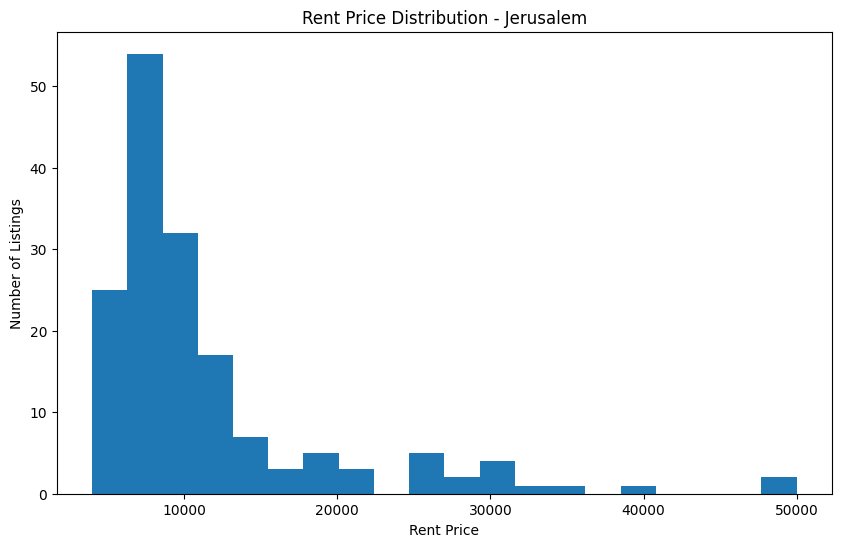

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(rent_final["price"], bins=20)

plt.title(f"Rent Price Distribution - {CITY_NAME}")
plt.xlabel("Rent Price")
plt.ylabel("Number of Listings")

plt.show()

## 15. EDA - Average Rent by Neighborhood

This analysis shows which neighborhoods have the highest average rent.

In [ ]:
avg_rent_neighborhood = (
    rent_neighborhood_filtered
    .groupby("Neighborhood")["price"]
    .mean()
    .sort_values(ascending=False)
)

avg_rent_neighborhood.head(10)

,price
Neighborhood,
Talbiya,17714.285714
German Colony,16040.909091
Katamon A-F,12900.000000
Rehavia,12433.333333
Kiryat HaYovel,12236.363636
Arnona (Talpiot),11734.615385
Nahlaot,10938.235294
City Center,10431.578947
Kiryat Shmuel,9660.000000


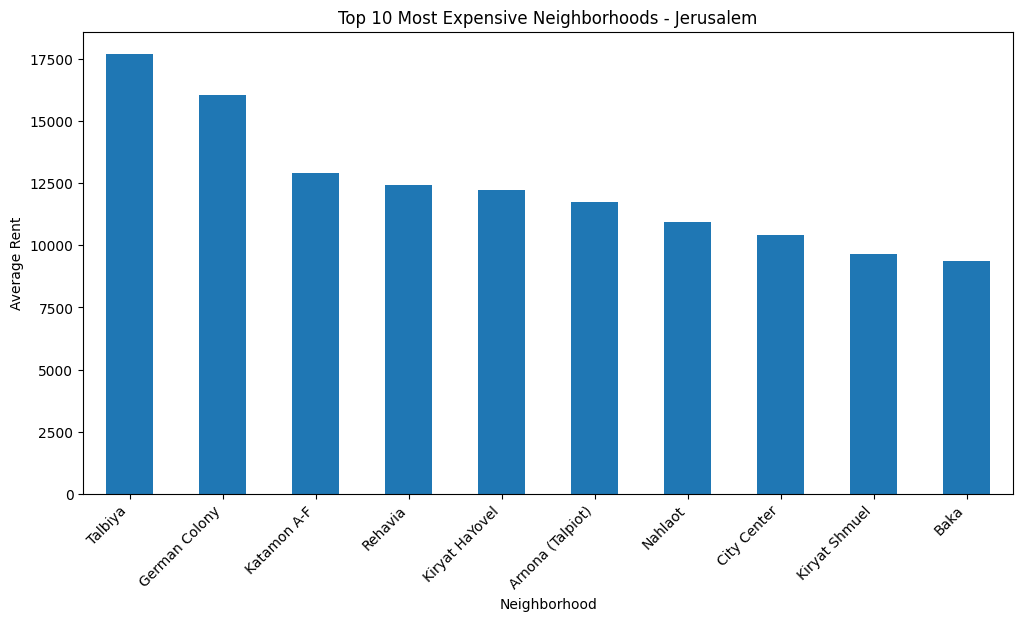

In [ ]:
top_neighborhoods = avg_rent_neighborhood.head(10)

plt.figure(figsize=(12, 6))
top_neighborhoods.plot(kind="bar")

plt.title(f"Top 10 Most Expensive Neighborhoods - {CITY_NAME}")
plt.xlabel("Neighborhood")
plt.ylabel("Average Rent")

plt.xticks(rotation=45, ha="right")
plt.show()

## 16. EDA - Cheapest Neighborhoods

This analysis shows the neighborhoods with the lowest average rent.

In [ ]:
cheapest_neighborhoods = (
    rent_neighborhood_filtered
    .groupby("Neighborhood")["price"]
    .mean()
    .sort_values(ascending=True)
)

cheapest_neighborhoods.head(10)

,price
Neighborhood,
Arnona Slopes,8792.142857
Baka,9388.461538
Kiryat Shmuel,9660.000000
City Center,10431.578947
Nahlaot,10938.235294
Arnona (Talpiot),11734.615385
Kiryat HaYovel,12236.363636
Rehavia,12433.333333
Katamon A-F,12900.000000


## 17. EDA - Rooms vs Rent Price

This analysis checks how rent price changes depending on the number of rooms.

In [ ]:
avg_rent_by_rooms = (
    rent_final
    .groupby("rooms")["price"]
    .mean()
    .sort_values()
)

avg_rent_by_rooms

,price
rooms,
2.0,6080.555556
1.5,7425.000000
2.5,7675.000000
3.0,8295.238095
3.5,8337.500000
7.0,9000.000000
4.0,11121.428571
4.5,12975.000000
5.5,14000.000000


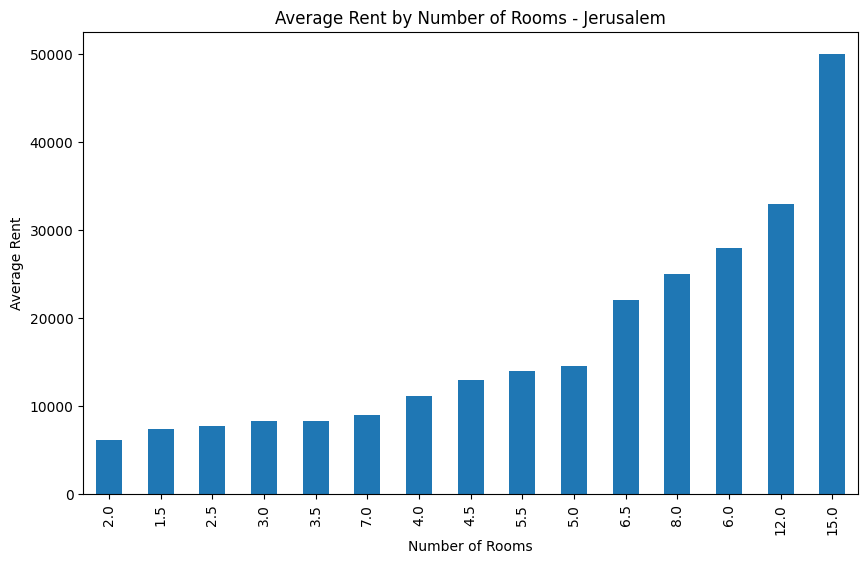

In [ ]:
plt.figure(figsize=(10, 6))
avg_rent_by_rooms.plot(kind="bar")

plt.title(f"Average Rent by Number of Rooms - {CITY_NAME}")
plt.xlabel("Number of Rooms")
plt.ylabel("Average Rent")

plt.show()

## 18. EDA - Price per Square Meter

Price per square meter is useful because it allows comparison between apartments of different sizes.

In [ ]:
avg_sqm_neighborhood = (
    rent_neighborhood_filtered
    .groupby("Neighborhood")["price_per_sqm"]
    .mean()
    .sort_values(ascending=False)
)

avg_sqm_neighborhood.head(10)

,price_per_sqm
Neighborhood,
City Center,129.956842
Talbiya,129.058571
Kiryat Shmuel,124.474000
Rehavia,119.645833
Nahlaot,116.870588
Katamon A-F,115.264000
German Colony,114.302727
Baka,112.832308
Arnona (Talpiot),95.156154


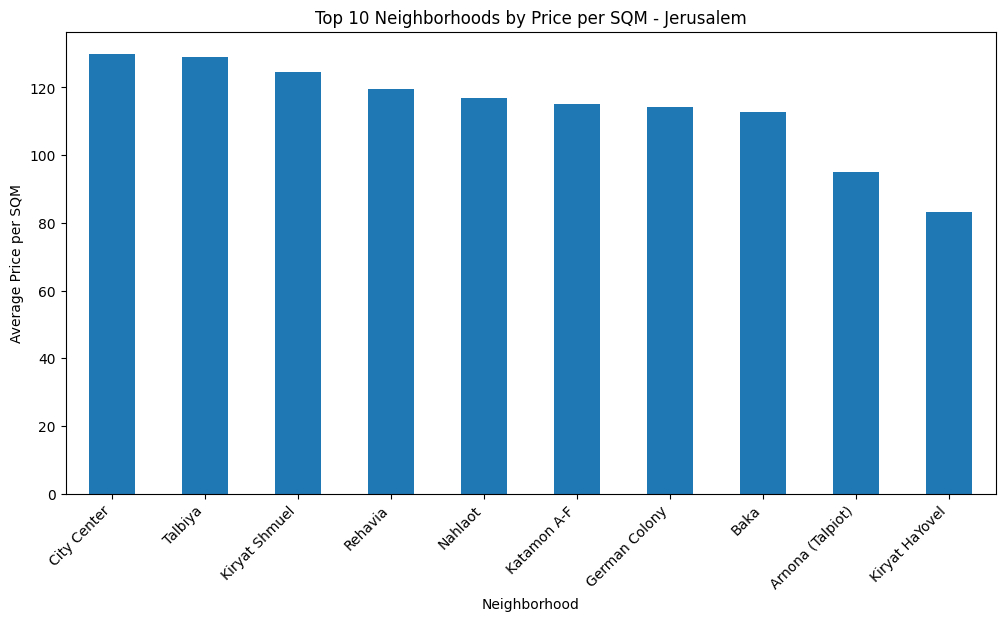

In [ ]:
top_sqm_neighborhoods = avg_sqm_neighborhood.head(10)

plt.figure(figsize=(12, 6))
top_sqm_neighborhoods.plot(kind="bar")

plt.title(f"Top 10 Neighborhoods by Price per SQM - {CITY_NAME}")
plt.xlabel("Neighborhood")
plt.ylabel("Average Price per SQM")

plt.xticks(rotation=45, ha="right")
plt.show()

## 19. Export Clean Dataset

Finally, I export the cleaned dataset as a CSV file.

This file will later be combined with other city datasets.

In [ ]:
# Export final clean dataset
rent_final.to_csv(OUTPUT_FILE, index=False)

print(f"File exported successfully: {OUTPUT_FILE}")

File exported successfully: jerusalem_rent_clean.csv
